# Initial Read

In [188]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [189]:
dataset = pd.read_csv("archive/portland_housing.csv")
dataset.head(3)

C:\Users\verma\AppData\Local\Temp\ipykernel_22312\2377862142.py:1: DtypeWarning: Columns (0: priceHistory/0/attributeSource/infoString1, 1: priceHistory/2/attributeSource/infoString1, 2: resoFacts/atAGlanceFacts/1/factValue, 3: resoFacts/hasHeating) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv("archive/portland_housing.csv")


,abbreviatedAddress,address/city,address/zipcode,bathrooms,bedrooms,brokerageName,dateSold,daysOnZillow,description,favoriteCount,...,taxHistory/0/taxPaid,taxHistory/0/time,taxHistory/0/value,taxHistory/0/valueIncreaseRate,url,yearBuilt,zestimate,zestimateHighPercent,zestimateLowPercent,zpid
0,2860 NE Blossom Hill Rd,Fairview,97024,3.0,3.0,NaN,1.621560e+12,25.0,"2860 NE Blossom Hill Rd, Fairview, OR 97024 is...",NaN,...,2989.74,1.592260e+12,172290.0,0.029950,https://www.zillow.com/homedetails/2860-NE-Blo...,2007.0,317406.0,5.0,5.0,72258538
1,20386 NE Mackenzie Ln,Fairview,97024,3.0,3.0,Harcourts Real Estate Network Group,1.619140e+12,53.0,Cute as a button 3bed/2.5bath home with brand ...,NaN,...,NaN,NaN,NaN,NaN,https://www.zillow.com/homedetails/20386-NE-Ma...,2001.0,NaN,NaN,NaN,2073593774
2,1121 SW 10th Dr,Gresham,97080,3.0,4.0,ERA Freeman & Associates,1.622760e+12,11.0,What a wonderful large home at end of quiet cu...,NaN,...,5178.62,1.592260e+12,282340.0,0.029987,https://www.zillow.com/homedetails/1121-SW-10t...,1982.0,512355.0,5.0,5.0,53959026


In [190]:
print(len(dataset))

25731


# Handling Missing values

In [191]:
missing_val = dataset.isnull().mean()*100
missing_val.sort_values(ascending=False).head()

resoFacts/securityFeatures/0                   80.649800
priceHistory/10/attributeSource/infoString2    79.965800
resoFacts/interiorFeatures/11                  79.814232
priceHistory/10/price                          79.705414
priceHistory/10/postingIsRental                79.612141
dtype: float64

In [192]:
# drop col with > 80% missing values
dataset = dataset.drop(columns=missing_val[missing_val>80].index)

In [193]:
miss_50_80 = missing_val[(missing_val>50) & (missing_val<=80)].index
dataset[miss_50_80].dtypes

favoriteCount                                 float64
priceHistory/0/buyerAgent/name                    str
priceHistory/0/buyerAgent/photo/url               str
priceHistory/0/buyerAgent/profileUrl              str
priceHistory/1/attributeSource/infoString1        str
                                               ...   
resoFacts/rooms/7/roomType                        str
resoFacts/subdivisionName                         str
resoFacts/view/0                                  str
resoFacts/waterViewYN                          object
resoFacts/windowFeatures/1                        str
Length: 119, dtype: object

In [194]:
# fill with median for numeric cols with missing val between 50% - 80%

numeric_50_80 = dataset[miss_50_80].select_dtypes(include='number').columns.tolist()
dataset[numeric_50_80] = dataset[numeric_50_80].fillna(dataset[numeric_50_80].median())
print(numeric_50_80)

['favoriteCount', 'priceHistory/6/price', 'priceHistory/6/priceChangeRate', 'priceHistory/6/pricePerSquareFoot', 'priceHistory/6/time', 'priceHistory/7/price', 'priceHistory/7/priceChangeRate', 'priceHistory/7/pricePerSquareFoot', 'priceHistory/7/time', 'priceHistory/8/price', 'priceHistory/8/priceChangeRate', 'priceHistory/8/pricePerSquareFoot', 'priceHistory/8/time', 'priceHistory/9/price', 'priceHistory/9/priceChangeRate', 'priceHistory/9/pricePerSquareFoot', 'priceHistory/9/time', 'priceHistory/10/price', 'priceHistory/10/priceChangeRate', 'priceHistory/10/time', 'resoFacts/rooms/3/roomArea', 'resoFacts/rooms/3/roomLength', 'resoFacts/rooms/3/roomWidth', 'resoFacts/rooms/4/roomArea', 'resoFacts/rooms/4/roomLength', 'resoFacts/rooms/4/roomWidth', 'resoFacts/rooms/5/roomArea', 'resoFacts/rooms/5/roomLength', 'resoFacts/rooms/5/roomWidth', 'resoFacts/rooms/6/roomArea', 'resoFacts/rooms/6/roomLength', 'resoFacts/rooms/6/roomWidth']


In [195]:
object_50_80 = dataset[miss_50_80].select_dtypes(exclude='number').columns.tolist()
object_50_80[:4]

['priceHistory/0/buyerAgent/name',
 'priceHistory/0/buyerAgent/photo/url',
 'priceHistory/0/buyerAgent/profileUrl',
 'priceHistory/1/attributeSource/infoString1']

In [196]:
# drop col with high and low uniqueness

cols_to_drop = [
    col for col in object_50_80
    if dataset[col].nunique() > 1500 or dataset[col].nunique() < 2
]

dataset.drop(columns=cols_to_drop, inplace=True)

object_50_80 = list(set(object_50_80) - set(cols_to_drop))

In [197]:
# fill with unknown

for col in object_50_80:
    dataset[col] = dataset[col].fillna("Unknown")

In [198]:
#  for 0 - 50 fill numeric col with median
missing_0_50 = missing_val[(missing_val<=50)].index
numeric_0_50 = dataset[missing_0_50].select_dtypes(include='number').columns.tolist()
dataset[numeric_0_50] = dataset[numeric_0_50].fillna(dataset[numeric_0_50].median())

print(numeric_0_50)

['address/zipcode', 'bathrooms', 'bedrooms', 'dateSold', 'daysOnZillow', 'lastSoldPrice', 'latitude', 'livingArea', 'longitude', 'lotSize', 'pageViewCount', 'price', 'priceHistory/0/price', 'priceHistory/0/priceChangeRate', 'priceHistory/0/pricePerSquareFoot', 'priceHistory/0/time', 'priceHistory/1/price', 'priceHistory/1/priceChangeRate', 'priceHistory/1/pricePerSquareFoot', 'priceHistory/1/time', 'priceHistory/2/price', 'priceHistory/2/priceChangeRate', 'priceHistory/2/pricePerSquareFoot', 'priceHistory/2/time', 'priceHistory/3/price', 'priceHistory/3/priceChangeRate', 'priceHistory/3/pricePerSquareFoot', 'priceHistory/3/time', 'priceHistory/4/price', 'priceHistory/4/priceChangeRate', 'priceHistory/4/pricePerSquareFoot', 'priceHistory/4/time', 'priceHistory/5/price', 'priceHistory/5/priceChangeRate', 'priceHistory/5/pricePerSquareFoot', 'priceHistory/5/time', 'propertyTaxRate', 'rentZestimate', 'resoFacts/fireplaces', 'resoFacts/onMarketDate', 'resoFacts/parking', 'resoFacts/rooms/0/

In [199]:
# object  type filled with unknown for now

obj_cols = dataset.select_dtypes(include='object').columns

for col in obj_cols:
    if dataset[col].isnull().sum() > 0:
        dataset[col] = dataset[col].fillna("Unknown")

C:\Users\verma\AppData\Local\Temp\ipykernel_22312\203179560.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = dataset.select_dtypes(include='object').columns


In [200]:
#  drop duplicates

dataset.drop_duplicates(inplace=True)

# Date Formatting

In [201]:
# convert years from float to int

dataset['yearBuilt'] = pd.to_numeric(dataset['yearBuilt'], errors='coerce').astype(int)
dataset['yearBuilt'].dtype

dtype('int64')

In [202]:
print('=== Before conversion in Unix timestamps in milliseconds: ===')
print(dataset['dateSold'][:4])

print('\n\n=== After conversion to datetime: ===')
dataset['dateSold'] = pd.to_datetime(dataset['dateSold'], unit='ms')
print(dataset['dateSold'][:4])

=== Before conversion in Unix timestamps in milliseconds: ===
0    1.621560e+12
1    1.619140e+12
2    1.622760e+12
3    1.622760e+12
Name: dateSold, dtype: float64


=== After conversion to datetime: ===
0   2021-05-21 01:20:00
1   2021-04-23 01:06:40
2   2021-06-03 22:40:00
3   2021-06-03 22:40:00
Name: dateSold, dtype: datetime64[ms]


In [203]:
dataset['taxHistory/0/time'] = pd.to_datetime(dataset['taxHistory/0/time'], unit='ms')
dataset['taxHistory/0/time'][:3]

0   2020-06-15 22:26:40
1   2020-07-22 23:20:00
2   2020-06-15 22:26:40
Name: taxHistory/0/time, dtype: datetime64[ms]

In [204]:
date_cols = [c for c in dataset.columns if c.endswith("/date")]

for col in date_cols:
    dataset[col] = pd.to_datetime(dataset[col], errors="coerce")

C:\Users\verma\AppData\Local\Temp\ipykernel_22312\1688442480.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset[col] = pd.to_datetime(dataset[col], errors="coerce")
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\1688442480.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset[col] = pd.to_datetime(dataset[col], errors="coerce")
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\1688442480.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset[col] = pd.to_datetime(dataset[col], errors="coerce")
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\16884424

# Cleaning

In [205]:
dataset['resoFacts/associationFee']

0             Unknown
1         $70 monthly
2             Unknown
3             Unknown
4             Unknown
             ...     
25726         Unknown
25727         Unknown
25728    $250 monthly
25729         Unknown
25730         Unknown
Name: resoFacts/associationFee, Length: 25731, dtype: str

In [206]:
# convert str to nan and numeric values

dataset['resoFacts/associationFee'] = (
    dataset['resoFacts/associationFee']
        .replace('Unknown', np.nan)
        .str.extract(r'([\d,]+)', expand=False)
        .str.replace(',', '', regex=False)
)

dataset['resoFacts/associationFee'] = pd.to_numeric(
    dataset['resoFacts/associationFee'],
    errors='coerce'
)

In [207]:
dataset[['resoFacts/hasAssociation', 'resoFacts/associationFee']].head()

,resoFacts/hasAssociation,resoFacts/associationFee
0,True,NaN
1,True,70.0
2,False,NaN
3,False,NaN
4,Unknown,NaN


In [208]:
print(dataset.groupby('resoFacts/homeType')['resoFacts/associationFee'].count())

print(dataset.groupby('address/zipcode')['resoFacts/associationFee'].count())

print(dataset.groupby('resoFacts/propertySubType/0')['resoFacts/associationFee'].count())

resoFacts/homeType
Apartment          0
Condo           1210
Cooperative        0
SingleFamily    4321
Townhouse       1106
Unknown            0
Name: resoFacts/associationFee, dtype: int64
address/zipcode
7123       0
97003    101
97004      1
97005     89
97006    216
        ... 
97233     51
97236    110
97239     57
97266     28
97267     35
Name: resoFacts/associationFee, Length: 65, dtype: int64
resoFacts/propertySubType/0
Apartment                     0
Attached                    558
Condo                        14
Condominium                1466
Farm                         15
Floating Home                12
Mixed Use                     6
MobileManufactured            0
Ranch                        71
Residence                     0
Single Family Residence    4072
SingleFamily                 52
Townhouse                   366
Unknown                       5
Name: resoFacts/associationFee, dtype: int64


In [209]:
# ----------------------------
# Step 1: HOA properties only
# ----------------------------
hoa = dataset[
    (dataset['resoFacts/hasAssociation'] == True) &
    (dataset['resoFacts/associationFee'].notna())
]

# Lookup tables
zip_median = hoa.groupby('address/zipcode')['resoFacts/associationFee'].median()

subtype_median = hoa.groupby('resoFacts/propertySubType/0')['resoFacts/associationFee'].median()

overall_median = hoa['resoFacts/associationFee'].median()

# ----------------------------
# Step 2: No association -> 0
# ----------------------------
dataset.loc[
    dataset['resoFacts/hasAssociation'] == False,
    'resoFacts/associationFee'
] = 0

# ----------------------------
# Step 3: ZIP code median
# ----------------------------
mask = (
    dataset['resoFacts/associationFee'].isna() &
    (dataset['resoFacts/hasAssociation'] != False)
)

dataset.loc[mask, 'resoFacts/associationFee'] = (
    dataset.loc[mask, 'address/zipcode'].map(zip_median)
)

# ----------------------------
# Step 4: Property subtype median
# ----------------------------
mask = dataset['resoFacts/associationFee'].isna()

dataset.loc[mask, 'resoFacts/associationFee'] = (
    dataset.loc[mask, 'resoFacts/propertySubType/0'].map(subtype_median)
)

# ----------------------------
# Step 5: Final fallback
# ----------------------------
dataset['resoFacts/associationFee'] = (
    dataset['resoFacts/associationFee']
    .fillna(overall_median)
)

zip_subtype_median = hoa.groupby(
    ['address/zipcode', 'resoFacts/propertySubType/0']
)['resoFacts/associationFee'].median()

In [210]:
#  convert boolean columns to 0 and 1

for col in dataset.columns:
    if(dataset[col].dtype == 'bool'):
        print(col)


bool_cols = dataset.select_dtypes(include=bool).columns
dataset[bool_cols] = dataset[bool_cols].astype(int)

priceHistory/0/postingIsRental
priceHistory/0/showCountyLink
resoFacts/furnished
resoFacts/hasAdditionalParcels
resoFacts/hasAttachedProperty
resoFacts/hasGarage
resoFacts/hasHomeWarranty
resoFacts/hasLandLease
resoFacts/hasPetsAllowed
resoFacts/hasSpa
resoFacts/hasView


In [211]:
#  convert boolean columns with unknown as entry (object col) to 0, 1, -1

bool_cols = [
    col for col in dataset.columns
    if dataset[col].dtype == 'object'
    and set(dataset[col].dropna().unique()).issubset({True, False, 'Unknown'})
]

mapping = {True: 1, False: 0, 'Unknown': -1}

for col in bool_cols:
    dataset[col] = dataset[col].map(mapping).astype(int)

In [212]:
cols = [
    'price',
    'bedrooms',
    'bathrooms',
    'livingArea',
    'lotSize',
    'yearBuilt',
    'resoFacts/stories',
    'resoFacts/parking'
]

dataset[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,25731.0,585191.748241,4.518907e+05,300.0,391000.0,522000.0,662200.0,41000000.0
bedrooms,25731.0,3.345692,9.883910e-01,0.0,3.0,3.0,4.0,43.0
bathrooms,25731.0,2.570137,1.001369e+00,0.0,2.0,3.0,3.0,23.0
livingArea,25731.0,2175.770705,1.119168e+03,0.0,1470.0,1996.0,2653.0,51290.0
lotSize,25731.0,25106.570829,1.310837e+06,0.0,4791.0,6969.0,9147.0,208722096.0
yearBuilt,25731.0,1975.188139,5.363377e+01,0.0,1954.0,1981.0,2003.0,2021.0
resoFacts/stories,25731.0,1.987991,6.535291e-01,1.0,2.0,2.0,2.0,7.0
resoFacts/parking,25731.0,1.506898,1.075891e+00,0.0,1.0,2.0,2.0,20.0


In [213]:
dataset[dataset['livingArea'] == 0]

dataset.loc[dataset['livingArea'] == 0, 'livingArea'] = np.nan
dataset['livingArea'].fillna(dataset['livingArea'].median(), inplace=True)

C:\Users\verma\AppData\Local\Temp\ipykernel_22312\3912816562.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataset['livingArea'].fillna(dataset['livingArea'].median(), inplace=True)


0        1806.0
1        1518.0
2        2724.0
3        1217.0
4        2400.0
          ...  
25726    1378.0
25727    2176.0
25728    1466.0
25729    1450.0
25730    2615.0
Name: livingArea, Length: 25731, dtype: float64

In [214]:
dataset['bedrooms'].value_counts().sort_index()

bedrooms
0.0        30
1.0       549
2.0      3240
3.0     11676
4.0      7722
5.0      2121
6.0       309
7.0        43
8.0        25
9.0        10
10.0        5
43.0        1
Name: count, dtype: int64

In [215]:
# Replace invalid 0 bedrooms with NaN
mask = (
    (dataset['bedrooms'] == 0) &
    (dataset['resoFacts/homeType'].isin(['SingleFamily', 'Townhouse']))
)

dataset.loc[mask, 'bedrooms'] = np.nan

# Fill using median bedrooms within home type
dataset['bedrooms'] = (
    dataset.groupby('resoFacts/homeType')['bedrooms']
           .transform(lambda x: x.fillna(x.median()))
)

In [216]:
mask = (
    (dataset['bathrooms'] == 0) &
    (dataset['resoFacts/homeType'].isin(['SingleFamily', 'Townhouse']))
)

dataset.loc[mask, 'bathrooms'] = np.nan

dataset['bathrooms'] = (
    dataset.groupby('resoFacts/homeType')['bathrooms']
           .transform(lambda x: x.fillna(x.median()))
)

In [217]:
price_cols = [
    col for col in dataset.columns
    if col.startswith('priceHistory/') and col.endswith('/price')
]

dataset.drop(columns=price_cols, inplace=True)
dataset.drop(columns=['lastSoldPrice'], inplace=True)

In [218]:
agent_cols = [
    col for col in dataset.columns
    if ('Agent' in col or
        'broker' in col.lower() or
        'profileUrl' in col or
        'photo' in col)
]

dataset.drop(columns=agent_cols, inplace=True)

In [219]:
# Correlation with price

corr = dataset.select_dtypes(include='number').corr()

corr['price'].sort_values(ascending=False).head(20)

price                                1.000000
zestimate                            0.681214
rentZestimate                        0.644845
livingArea                           0.529570
priceHistory/0/pricePerSquareFoot    0.429709
bathrooms                            0.377711
resoFacts/fireplaces                 0.312964
taxAssessedValue                     0.302342
bedrooms                             0.301634
taxHistory/0/value                   0.289824
restimateLowPercent                  0.282518
taxHistory/0/taxPaid                 0.254982
schools/2/rating                     0.227914
schools/0/rating                     0.227544
resoFacts/rooms/0/roomArea           0.219625
priceHistory/1/pricePerSquareFoot    0.218736
resoFacts/rooms/1/roomArea           0.217348
resoFacts/parking                    0.215346
resoFacts/stories                    0.212577
priceHistory/2/pricePerSquareFoot    0.212155
Name: price, dtype: float64

# Feature Engineering

In [220]:
dataset['soldYear'] = dataset['dateSold'].dt.year
dataset['soldMonth'] = dataset['dateSold'].dt.month
dataset['soldQuarter'] = dataset['dateSold'].dt.quarter
dataset['propertyAge'] = dataset['soldYear'] - dataset['yearBuilt']
dataset['daysListedPerArea'] = dataset['daysOnZillow'] / dataset['livingArea']

C:\Users\verma\AppData\Local\Temp\ipykernel_22312\2006903140.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['soldYear'] = dataset['dateSold'].dt.year
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\2006903140.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['soldMonth'] = dataset['dateSold'].dt.month
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\2006903140.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

In [221]:
dataset['PricePerSqft'] = dataset['price'] / dataset['livingArea']

dataset['LotAreaRatio'] = dataset['livingArea'] / dataset['lotSize']

dataset['BathroomBedroomRatio'] = dataset['bathrooms'] / dataset['bedrooms']

dataset['TaxToPriceRatio'] = dataset['taxAssessedValue'] / dataset['price']

C:\Users\verma\AppData\Local\Temp\ipykernel_22312\2791619338.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['PricePerSqft'] = dataset['price'] / dataset['livingArea']
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\2791619338.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['LotAreaRatio'] = dataset['livingArea'] / dataset['lotSize']
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\2791619338.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert`

In [222]:
dataset['ViewsPerDay'] = dataset['pageViewCount'] / (dataset['daysOnZillow'] + 1)

dataset['FavoritesPerView'] = dataset['favoriteCount'] / (dataset['pageViewCount'] + 1)

C:\Users\verma\AppData\Local\Temp\ipykernel_22312\420411325.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['ViewsPerDay'] = dataset['pageViewCount'] / (dataset['daysOnZillow'] + 1)
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\420411325.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['FavoritesPerView'] = dataset['favoriteCount'] / (dataset['pageViewCount'] + 1)


In [223]:
school_rating_cols = [
    'schools/0/rating',
    'schools/1/rating',
    'schools/2/rating'
]

school_dist_cols = [
    'schools/0/distance',
    'schools/1/distance',
    'schools/2/distance'
]

dataset['AvgSchoolRating'] = dataset[school_rating_cols].mean(axis=1)
dataset['MaxSchoolRating'] = dataset[school_rating_cols].max(axis=1)
dataset['MinSchoolDistance'] = dataset[school_dist_cols].min(axis=1)

C:\Users\verma\AppData\Local\Temp\ipykernel_22312\3762364532.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['AvgSchoolRating'] = dataset[school_rating_cols].mean(axis=1)
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\3762364532.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['MaxSchoolRating'] = dataset[school_rating_cols].max(axis=1)
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\3762364532.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.i

In [224]:
def count_features(cols):
    return dataset[cols].notna().sum(axis=1)

In [225]:
appliance_cols = [c for c in dataset.columns if 'appliances' in c]
dataset['numAppliances'] = count_features(appliance_cols)

C:\Users\verma\AppData\Local\Temp\ipykernel_22312\1156643153.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['numAppliances'] = count_features(appliance_cols)


In [226]:
interior_cols = [c for c in dataset.columns if 'interiorFeatures' in c]
dataset['numInteriorFeatures'] = count_features(interior_cols)

exterior_cols = [c for c in dataset.columns if 'exteriorFeatures' in c]
dataset['numExteriorFeatures'] = count_features(exterior_cols)

room_cols = [c for c in dataset.columns if 'rooms' in c and 'roomType' in c]
dataset['numRooms'] = count_features(room_cols)

C:\Users\verma\AppData\Local\Temp\ipykernel_22312\2012088400.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['numInteriorFeatures'] = count_features(interior_cols)
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\2012088400.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['numExteriorFeatures'] = count_features(exterior_cols)
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\2012088400.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many time

In [227]:
price_change_cols = [c for c in dataset.columns if 'priceHistory' in c and 'priceChangeRate' in c]

dataset['avgPriceChangeRate'] = dataset[price_change_cols].mean(axis=1)
dataset['priceVolatility'] = dataset[price_change_cols].std(axis=1)

dataset['priceHistoryCount'] = dataset[price_change_cols].notna().sum(axis=1)

C:\Users\verma\AppData\Local\Temp\ipykernel_22312\3992720556.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['avgPriceChangeRate'] = dataset[price_change_cols].mean(axis=1)
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\3992720556.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['priceVolatility'] = dataset[price_change_cols].std(axis=1)
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\3992720556.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.ins

In [228]:
dataset['IsLuxury'] = df["IsLuxury"] = (df["price"] > df["price"].quantile(0.9)).astype(int)
dataset['IsLargeHome'] = (dataset['livingArea'] > dataset['livingArea'].median()).astype(int)

C:\Users\verma\AppData\Local\Temp\ipykernel_22312\315652775.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['IsLuxury'] = df["IsLuxury"] = (df["price"] > df["price"].quantile(0.9)).astype(int)
C:\Users\verma\AppData\Local\Temp\ipykernel_22312\315652775.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['IsLargeHome'] = (dataset['livingArea'] > dataset['livingArea'].median()).astype(int)


In [229]:
price_history_cols = [c for c in dataset.columns if 'priceHistory/' in c]
dataset.drop(columns=price_history_cols, inplace=True, errors='ignore')

drop_keywords = [
    'appliances/',
    'interiorFeatures/',
    'exteriorFeatures/',
    'rooms/',
    'flooring/',
    'parkingFeatures/',
    'accessibilityFeatures/',
    'lotFeatures/',
    'patioAndPorchFeatures/'
]

drop_cols = [c for c in dataset.columns if any(k in c for k in drop_keywords)]
dataset.drop(columns=drop_cols, inplace=True, errors='ignore')

dataset.drop(columns=[
    'description',
    'postingContact/name',
    'abbreviatedAddress'
], inplace=True, errors='ignore')

dataset.drop(columns=[
    'pageViewCount',
    'favoriteCount',
    'daysOnZillow'
], inplace=True, errors='ignore')

In [230]:
dataset.drop(columns=[
    'description',
    'postingContact/name',
    'abbreviatedAddress',
    'url',
    'zpid',
    'parcelNumber'
], inplace=True, errors='ignore')

In [231]:
school_raw_cols = [c for c in dataset.columns if 'schools/' in c]
dataset.drop(columns=school_raw_cols, inplace=True, errors='ignore')

In [232]:
drop_keywords = [
    'appliances/',
    'interiorFeatures/',
    'exteriorFeatures/',
    'rooms/',
    'flooring/',
    'parkingFeatures/',
    'accessibilityFeatures/',
    'lotFeatures/',
    'patioAndPorchFeatures/',
    'windowFeatures/',
    'laundryFeatures/'
]

drop_cols = [c for c in dataset.columns if any(k in c for k in drop_keywords)]

dataset.drop(columns=drop_cols, inplace=True, errors='ignore')

In [233]:
print(dataset.shape)

dataset.head()

(25731, 116)


,address/city,address/zipcode,bathrooms,bedrooms,dateSold,homeStatus,homeType,latitude,livingArea,longitude,...,MinSchoolDistance,numAppliances,numInteriorFeatures,numExteriorFeatures,numRooms,avgPriceChangeRate,priceVolatility,priceHistoryCount,IsLuxury,IsLargeHome
0,Fairview,97024,3.0,3.0,2021-05-21 01:20:00,RECENTLY_SOLD,TOWNHOUSE,45.543571,1806.0,-122.441765,...,0.4,9,12,3,8,0.050081,0.146385,11,0,0
1,Fairview,97024,3.0,3.0,2021-04-23 01:06:40,RECENTLY_SOLD,SINGLE_FAMILY,45.547585,1518.0,-122.453224,...,1.0,9,12,3,8,0.006061,0.020101,11,0,0
2,Gresham,97080,3.0,4.0,2021-06-03 22:40:00,RECENTLY_SOLD,SINGLE_FAMILY,45.488228,2724.0,-122.444420,...,0.8,9,12,3,8,0.147596,0.467130,11,0,1
3,Portland,97230,1.0,3.0,2021-06-03 22:40:00,RECENTLY_SOLD,SINGLE_FAMILY,45.526634,1217.0,-122.464088,...,0.7,9,12,3,8,0.002276,0.007549,11,0,0
4,Gresham,97030,3.0,6.0,2021-06-01 01:13:20,RECENTLY_SOLD,APARTMENT,45.511238,2400.0,-122.431534,...,0.3,9,12,3,8,0.125891,0.316134,11,0,1


Outliers: 1485 (5.8%)


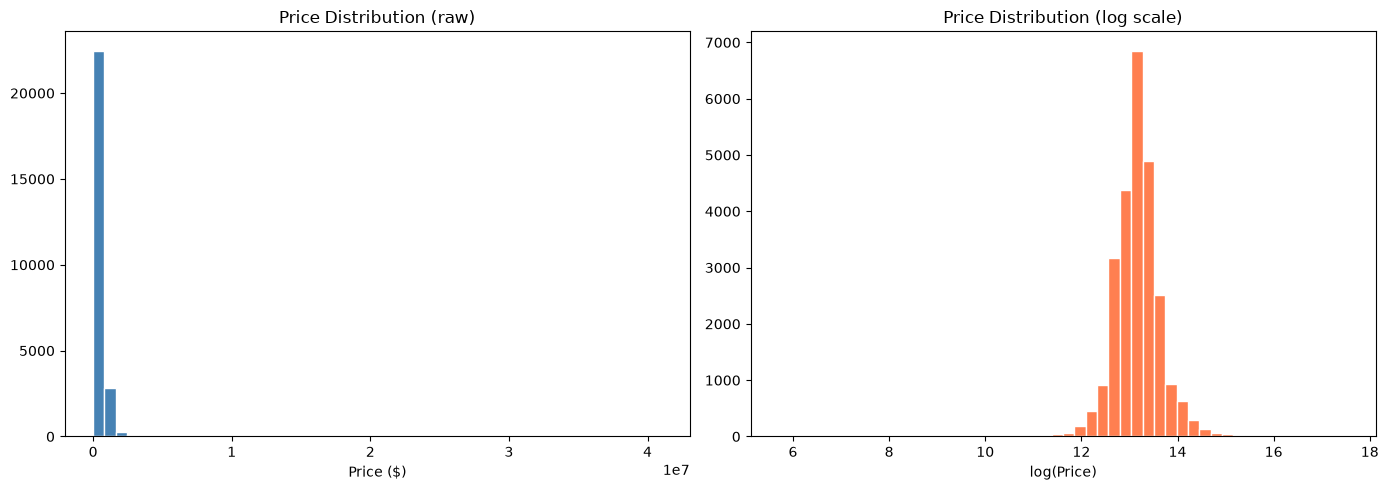

In [234]:
# Price outliers using IQR
Q1 = dataset['price'].quantile(0.25)
Q3 = dataset['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = dataset[(dataset['price'] < lower) | (dataset['price'] > upper)]
print(f"Outliers: {len(outliers)} ({len(outliers)/len(dataset)*100:.1f}%)")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(dataset['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (raw)')
axes[0].set_xlabel('Price ($)')

axes[1].hist(np.log1p(dataset['price']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Price Distribution (log scale)')
axes[1].set_xlabel('log(Price)')
plt.tight_layout()
plt.show()

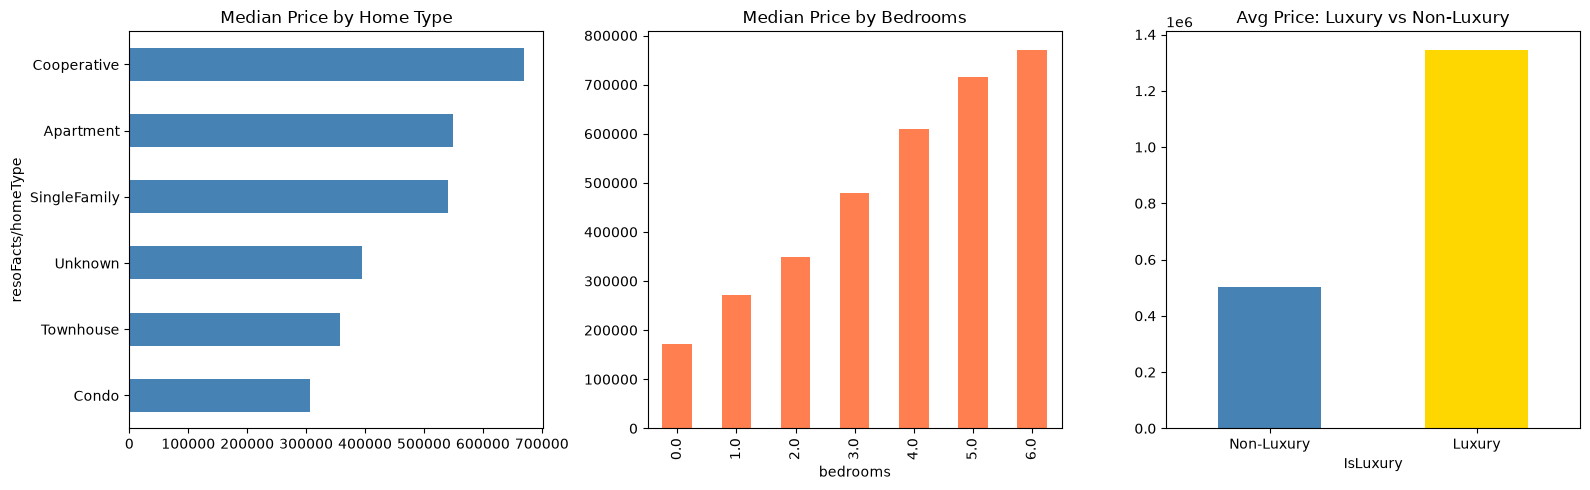

In [235]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By home type
dataset.groupby('resoFacts/homeType')['price'].median().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Median Price by Home Type')

# By bedrooms
dataset[dataset['bedrooms'] <= 6].groupby('bedrooms')['price'].median().plot(
    kind='bar', ax=axes[1], color='coral'
)
axes[1].set_title('Median Price by Bedrooms')

# Luxury vs non-luxury
dataset.groupby('IsLuxury')['price'].mean().plot(
    kind='bar', ax=axes[2], color=['steelblue', 'gold']
)
axes[2].set_title('Avg Price: Luxury vs Non-Luxury')
axes[2].set_xticklabels(['Non-Luxury', 'Luxury'], rotation=0)

plt.tight_layout()
plt.show()

                         mean    median  count
school_tier                                   
Poor (<4)       468665.801259  450000.0   5560
Average (4-6)   529763.669417  499000.0  11271
Good (6-8)      674288.003929  590235.0   7127
Excellent (8+)  944822.389735  784500.0   1773


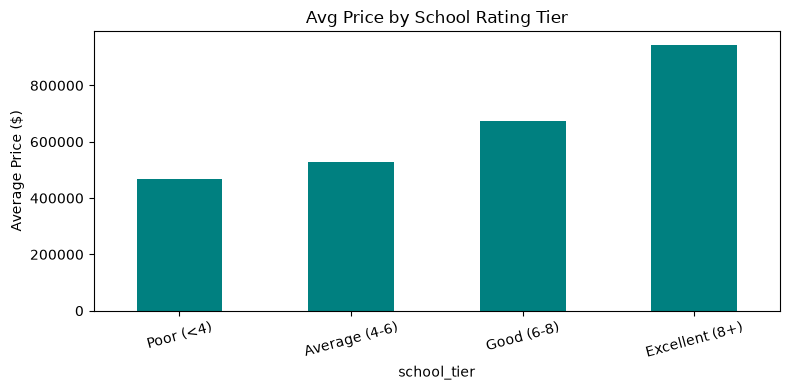

In [236]:
# Bin school ratings
dataset['school_tier'] = pd.cut(
    dataset['AvgSchoolRating'],
    bins=[0, 4, 6, 8, 10],
    labels=['Poor (<4)', 'Average (4-6)', 'Good (6-8)', 'Excellent (8+)']
)

school_price = dataset.groupby('school_tier')['price'].agg(['mean', 'median', 'count'])
print(school_price)

school_price['mean'].plot(kind='bar', color='teal', figsize=(8, 4))
plt.title('Avg Price by School Rating Tier')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

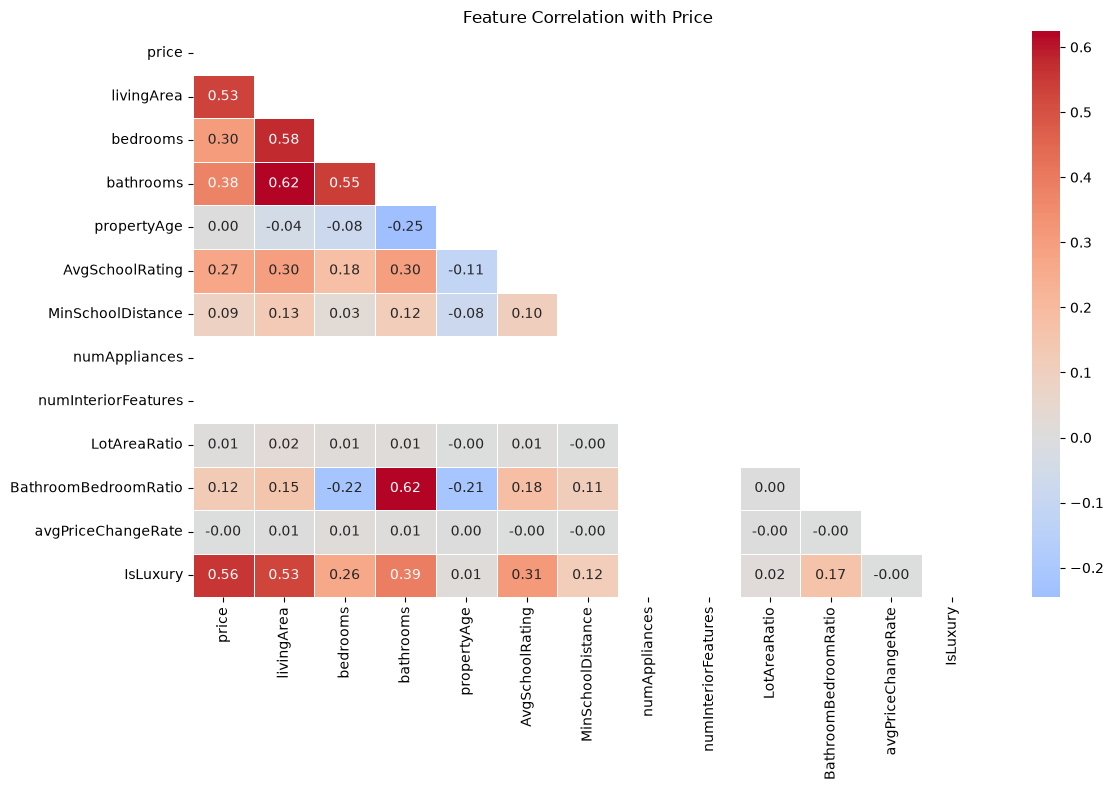

In [237]:
key_features = [
    'price', 'livingArea', 'bedrooms', 'bathrooms',
    'propertyAge', 'AvgSchoolRating', 'MinSchoolDistance',
    'numAppliances', 'numInteriorFeatures', 'LotAreaRatio',
    'BathroomBedroomRatio', 'avgPriceChangeRate', 'IsLuxury'
]

corr = dataset[key_features].corr()

plt.figure(figsize=(12, 8))
import seaborn as sns
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation with Price')
plt.tight_layout()
plt.show()

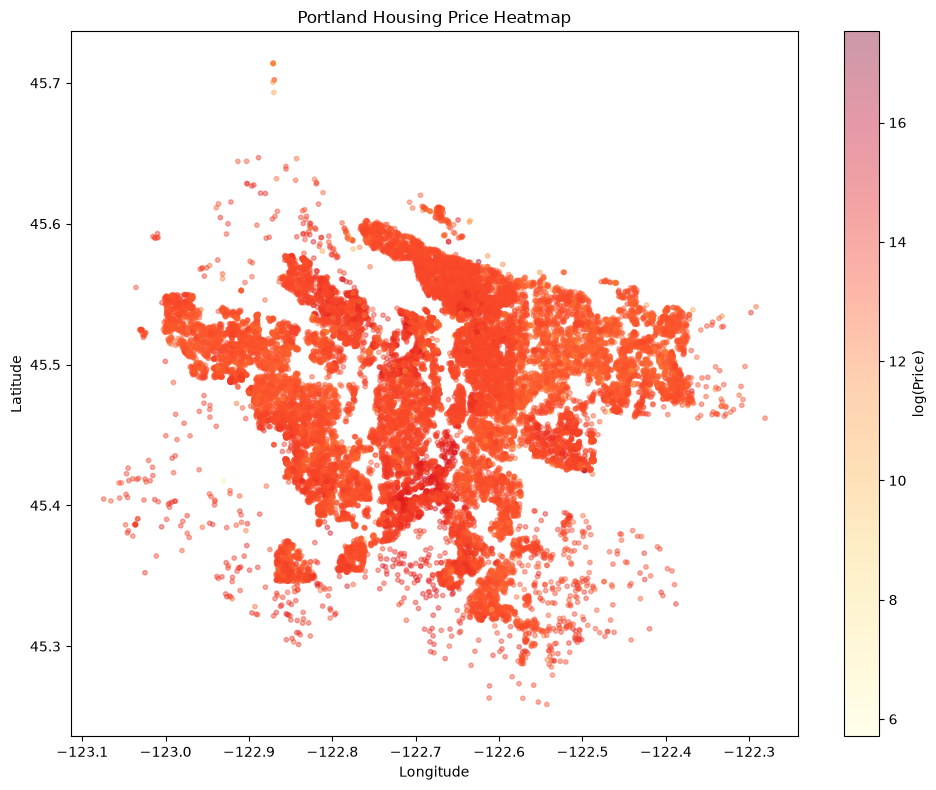

In [238]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    dataset['longitude'], 
    dataset['latitude'],
    c=np.log1p(dataset['price']),
    cmap='YlOrRd',
    alpha=0.4,
    s=10
)
plt.colorbar(scatter, label='log(Price)')
plt.title('Portland Housing Price Heatmap')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

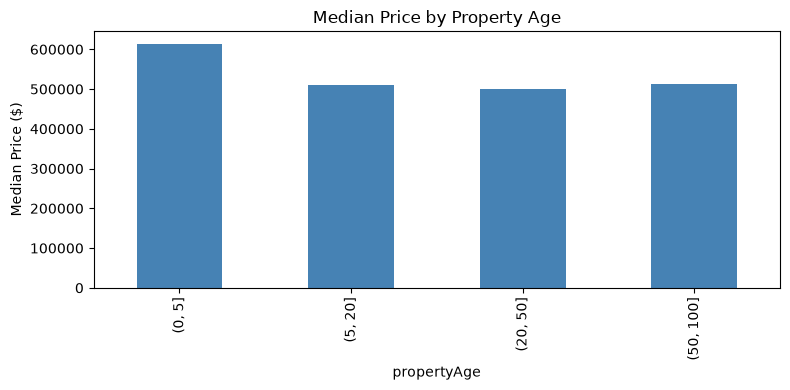

C:\Users\verma\AppData\Local\Temp\ipykernel_22312\4123191863.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset, x='resoFacts/homeType', y='price', palette='muted')


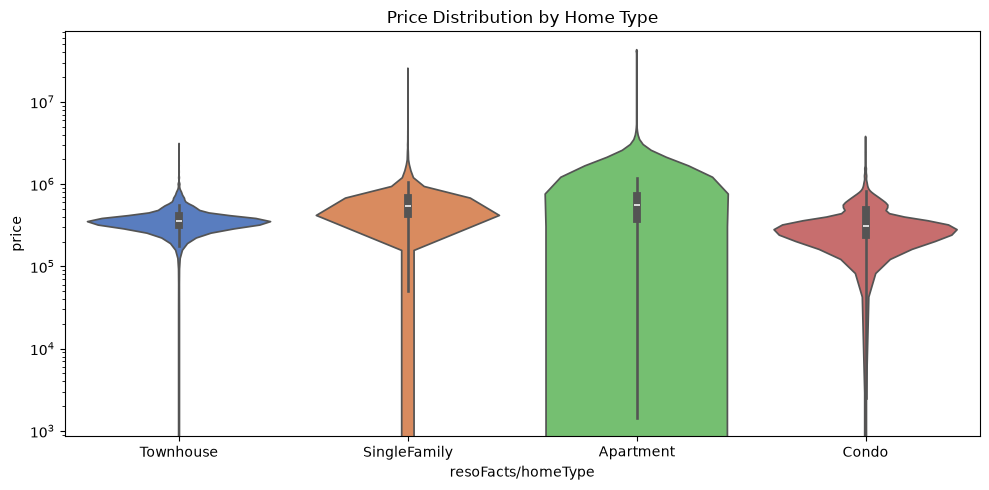

In [239]:
# 1. Price vs Property Age — does newer = pricier?
age_price = dataset.groupby(
    pd.cut(dataset['propertyAge'], bins=[0,5,20,50,100])
)['price'].median()
age_price.plot(kind='bar', figsize=(8,4), color='steelblue')
plt.title('Median Price by Property Age')
plt.ylabel('Median Price ($)')
plt.tight_layout()
plt.show()

# 2. Days on market vs price — do expensive homes sit longer?
# plt.figure(figsize=(8,5))
# plt.scatter(dataset['daysOnZillow'], dataset['price'], 
#             alpha=0.2, s=8, color='coral')
# plt.xlabel('Days on Zillow')
# plt.ylabel('Price ($)')
# plt.title('Days on Market vs Price')
# plt.yscale('log')
# plt.tight_layout()
# plt.show()

# 3. Violin plot — price distribution by home type
import seaborn as sns
top_types = dataset['resoFacts/homeType'].value_counts().head(4).index
subset = dataset[dataset['resoFacts/homeType'].isin(top_types)]

plt.figure(figsize=(10,5))
sns.violinplot(data=subset, x='resoFacts/homeType', y='price', palette='muted')
plt.yscale('log')
plt.title('Price Distribution by Home Type')
plt.tight_layout()
plt.show()

In [240]:
from scipy import stats

skewed_cols = ['price', 'livingArea', 'lotSize', 'PricePerSqft']

print("Skewness Analysis:")
print("-" * 40)
for col in skewed_cols:
    skew = dataset[col].skew()
    flag = " ← needs log transform" if abs(skew) > 1 else ""
    print(f"{col:<25} skew: {skew:>6.2f}{flag}")

Skewness Analysis:
----------------------------------------
price                     skew:  36.12 ← needs log transform
livingArea                skew:   6.39 ← needs log transform
lotSize                   skew: 157.00 ← needs log transform
PricePerSqft              skew:  66.85 ← needs log transform


In [241]:
print("=== Dataset Summary After Cleaning ===")
print(f"Total properties: {len(dataset):,}")
print(f"Price range: ${dataset['price'].min():,.0f} — ${dataset['price'].max():,.0f}")
print(f"Median price: ${dataset['price'].median():,.0f}")
print(f"Luxury homes (top 10%): {dataset['IsLuxury'].sum():,} ({dataset['IsLuxury'].mean()*100:.1f}%)")
print(f"Avg school rating: {dataset['AvgSchoolRating'].mean():.1f}/10")
print(f"Most common home type: {dataset['resoFacts/homeType'].mode()[0]}")
print(f"Years covered: {dataset['soldYear'].min()} — {dataset['soldYear'].max()}")

=== Dataset Summary After Cleaning ===
Total properties: 25,731
Price range: $300 — $41,000,000
Median price: $522,000
Luxury homes (top 10%): 2,556 (9.9%)
Avg school rating: 5.5/10
Most common home type: SingleFamily
Years covered: 2020 — 2021


In [242]:
print("Rows with price > 5M:", (dataset['price'] > 5_000_000).sum())
print("Rows with price < 10K:", (dataset['price'] < 10_000).sum())
print("Rows with lotSize > 500K:", (dataset['lotSize'] > 500_000).sum())
print("Rows with livingArea > 10K:", (dataset['livingArea'] > 10_000).sum())
print("Rows with PricePerSqft == 0:", (dataset['PricePerSqft'] == 0).sum())
print("Total rows currently:", len(dataset))

Rows with price > 5M: 7
Rows with price < 10K: 41
Rows with lotSize > 500K: 82
Rows with livingArea > 10K: 20
Rows with PricePerSqft == 0: 0
Total rows currently: 25731


In [243]:
print(f"Before: {len(dataset):,} rows")

# Drop bad rows
dataset = dataset[dataset['price'] >= 10_000]
dataset = dataset[dataset['price'] <= 5_000_000]
dataset = dataset[dataset['lotSize'] <= 500_000]
dataset = dataset[dataset['livingArea'] <= 10_000]

# Recalculate PricePerSqft cleanly after dropping bad rows
dataset['PricePerSqft'] = dataset['price'] / dataset['livingArea']

print(f"After:  {len(dataset):,} rows")
print(f"Removed: {25731 - len(dataset)} rows ({(25731 - len(dataset))/25731*100:.1f}%)")

Before: 25,731 rows
After:  25,585 rows
Removed: 146 rows (0.6%)


In [244]:
for col in ['price', 'livingArea', 'lotSize', 'PricePerSqft']:
    dataset[f'log_{col}'] = np.log1p(dataset[col])

print("\nSkewness after dropping outliers + log transform:")
for col in ['price', 'livingArea', 'lotSize', 'PricePerSqft']:
    print(f"{col:<15} raw: {dataset[col].skew():>7.2f}   log: {dataset[f'log_{col}'].skew():>5.2f}")


Skewness after dropping outliers + log transform:
price           raw:    3.65   log: -0.35
livingArea      raw:    1.52   log: -0.15
lotSize         raw:    8.97   log:  0.89
PricePerSqft    raw:    7.84   log: -1.33


In [245]:
dataset.to_csv("structure_portland_data.csv")